    k  accuracy
0   1     0.875
1   3     1.000
2   5     0.875
3   7     0.875
4   9     0.875
5  11     0.875
6  15     0.500


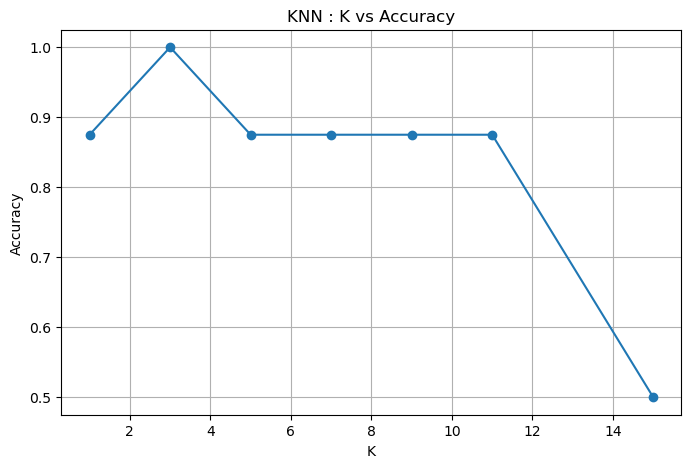

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# ==========================
# 1. 데이터 생성
# ==========================

np.random.seed(42)

study = []
game = []
passed = []

# 불합격 그룹
for _ in range(50):

    s = np.random.normal(3, 1)
    g = np.random.normal(8, 1)

    study.append(s)
    game.append(g)
    passed.append(0)


# 합격 그룹
for _ in range(50):

    s = np.random.normal(8, 1)
    g = np.random.normal(3, 1)

    study.append(s)
    game.append(g)
    passed.append(1)


# 일부러 경계 데이터 추가 (노이즈)
noise = [
    [5,5,0],
    [5.2,5.1,1],
    [5.1,5.0,0],
    [4.9,5.3,1],
    [5.3,4.8,0],
    [5.4,5.2,1],
]

for s,g,p in noise:
    study.append(s)
    game.append(g)
    passed.append(p)


df = pd.DataFrame({
    "study": study,
    "game": game,
    "pass": passed
})

df = pd.DataFrame({

    "study":[
        1,1,2,2,2,
        3,3,3,4,4,
        5,5,5,5,6,
        6,6,7,7,8,
        8,9,9,10
    ],

    "game":[
        9,8,9,8,7,
        8,7,6,7,6,
        5,6,4,5,4,
        5,3,4,2,3,
        2,2,1,1
    ],

    "pass":[
        0,0,0,0,0,
        0,0,1,0,1,
        0,1,0,1,0,
        1,1,1,1,1,
        1,1,1,1
    ]
})
# ==========================
# 2. X / y
# ==========================

X = df[["study","game"]]
y = df["pass"]


# ==========================
# 3. train / test
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=7,
    stratify=y
)


# ==========================
# 4. scaling
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ==========================
# 5. K 비교
# ==========================

results=[]

k_list=[1,3,5,7,9,11,15]

for k in k_list:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append([
        k,
        acc
    ])


result_df = pd.DataFrame(
    results,
    columns=[
        "k",
        "accuracy"
    ]
)

print(result_df)


# ==========================
# 6. 그래프
# ==========================

plt.figure(figsize=(8,5))

plt.plot(
    result_df["k"],
    result_df["accuracy"],
    marker="o"
)

plt.title("KNN : K vs Accuracy")

plt.xlabel("K")

plt.ylabel("Accuracy")

plt.grid()

plt.show()